# FlowMap pancreas tutorial

This notebook shows a minimal, reproducible FlowMap workflow on the scVelo pancreas dataset. We recompute PCA, fit FlowMap on the existing UMAP embedding, and evaluate reconstruction at the PC and gene levels.


## 1. Load data

Download the AnnData file manually from Figshare to ensure the same cells and genes are used each time:

https://figshare.com/articles/dataset/scvelo-pancreas_h5ad/16547649?file=30595479

Place the file at `data/scvelo-pancreas.h5ad`, or update `DATA_PATH` below.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import scvelo as scv
from matplotlib.colors import LinearSegmentedColormap
from scipy import sparse
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from flowmap import VectorFieldEmbedder
from flowmap.evaluation import SplineFitEvaluator
from flowmap.plot import plot_2d_quiver, plot_velocity_grid

DATA_PATH = Path("data/scvelo-pancreas.h5ad")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Download the pancreas AnnData file from Figshare and place it at "
        f"{DATA_PATH}."
    )

adata = sc.read_h5ad(DATA_PATH)
adata


AnnData object with n_obs × n_vars = 3696 × 1945
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'initial_size_spliced', 'initial_size_unspliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'phase', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition', 'root_cells', 'end_points', 'velocity_pseudotime', 'latent_time'
    var: 'highly_variable_genes', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes', 'spearmans_score', 'velocity_score', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'fit_r2'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'clusters_sizes', 'day_colors', 'neighbors', 'paga', 'pca', 'rank_dynamical_genes', 'rank_velocity_genes', 'recover_dynami

## 2. Recompute PCA and velocity

When the input dimension is high, such as thousands of genes, it is usually better to perform the embedding-level FlowMap fit in PC space. Here we recompute PCA locally, then project stochastic RNA velocity into the same PCA basis.


In [2]:
def to_dense(x):
    return x.toarray() if sparse.issparse(x) else np.asarray(x)


def get_hvg_mask(adata):
    for key in ["highly_variable", "highly_variable_genes"]:
        if key in adata.var:
            values = adata.var[key]
            if values.dtype == bool:
                return values.to_numpy()
            return values.astype(str).str.lower().isin(["true", "1"]).to_numpy()
    return np.ones(adata.n_vars, dtype=bool)


hvg_mask = get_hvg_mask(adata)
X_scaled = StandardScaler().fit_transform(to_dense(adata[:, hvg_mask].X))

n_pcs = 50
pca = PCA(n_components=n_pcs, svd_solver="arpack", random_state=0)
adata.obsm["X_pca"] = pca.fit_transform(X_scaled)

pcs = np.zeros((adata.n_vars, n_pcs), dtype=float)
pcs[hvg_mask] = pca.components_.T
adata.varm["PCs"] = pcs
adata.uns["pca"] = {
    "variance": pca.explained_variance_,
    "variance_ratio": pca.explained_variance_ratio_,
}

scv.tl.velocity(adata, vkey="stochastic_velocity", mode="stochastic")
scv.tl.velocity_graph(adata, vkey="stochastic_velocity")
scv.tl.velocity_embedding(adata, basis="pca", vkey="stochastic_velocity")

X_pca = np.asarray(adata.obsm["X_pca"])
V_pca = np.asarray(adata.obsm["stochastic_velocity_pca"])
X_emb = np.asarray(adata.obsm["X_umap"])

cell_type_key = "clusters"
cell_type = adata.obs[cell_type_key].astype(str).to_numpy()


computing velocities
    finished (0:00:00) --> added 
    'stochastic_velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/18 cores)
or disable the progress bar using `show_progress_bar=False`.
    finished (0:00:04) --> added 
    'stochastic_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'stochastic_velocity_pca', embedded velocity vectors (adata.obsm)


## 3. Fit splines on the existing embedding

FlowMap can work with an existing embedding. Passing `X_emb` tells FlowMap to keep the given UMAP coordinates and fit the spline maps directly on that embedding.


In [3]:
emb = VectorFieldEmbedder(
    X_pca,
    V_pca,
    X_emb=X_emb,
    use_PCA=False,
    method="umap",
    dist_method="euclidean",
)

emb.fit_embedding(seed=0)


[Spline] Fitting manifold spline on 3696 cells …
[Spline] Using all 3696 points as control points.
[Spline] Mapping vector field …
[Spline] Fitting velocity spline …
[Spline] Using all 3696 points as control points.
[FlowMap] Done.


## 4. Embedded velocity grid

The grid plot evaluates the fitted embedded vector field on a regular grid.


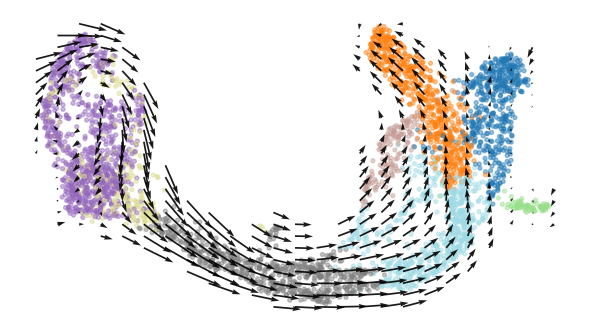

In [4]:
fig = plot_velocity_grid(
    emb.X_emb,
    spline_vf=emb.spline_vf,
    scatter_color=cell_type,
    grid_size=25,
    scatter_size=8,
    scatter_alpha=0.45,
    arrow_scale=0.1,
    arrow_width=0.003,
    cmap="tab20",
    figsize=(6, 5),
)
plt.show()


## 5. Cell-type-level evaluation

We evaluate the embedding-level spline separately within each cell type and summarize the result per principal component.


In [5]:
def evaluate_pcs_by_cell_type(evaluator, labels, n_pcs=10, min_cells=10):
    pc_labels = [f"PC{i + 1}" for i in range(n_pcs)]
    expr_rows, vel_rows = [], []

    for label in pd.unique(labels):
        idx = np.where(labels == label)[0]
        if len(idx) < min_cells:
            continue

        result = evaluator.evaluate(cell_idx=idx)
        expr_rows.append(pd.Series(result["expr_corr_gene"][:n_pcs], index=pc_labels, name=label))
        vel_rows.append(pd.Series(result["vel_corr_gene"][:n_pcs], index=pc_labels, name=label))

    return pd.DataFrame(expr_rows), pd.DataFrame(vel_rows)

pc_expr_scores, pc_vel_scores = evaluate_pcs_by_cell_type(
    SplineFitEvaluator(emb, mode="default"),
    cell_type,
    n_pcs=10,
)


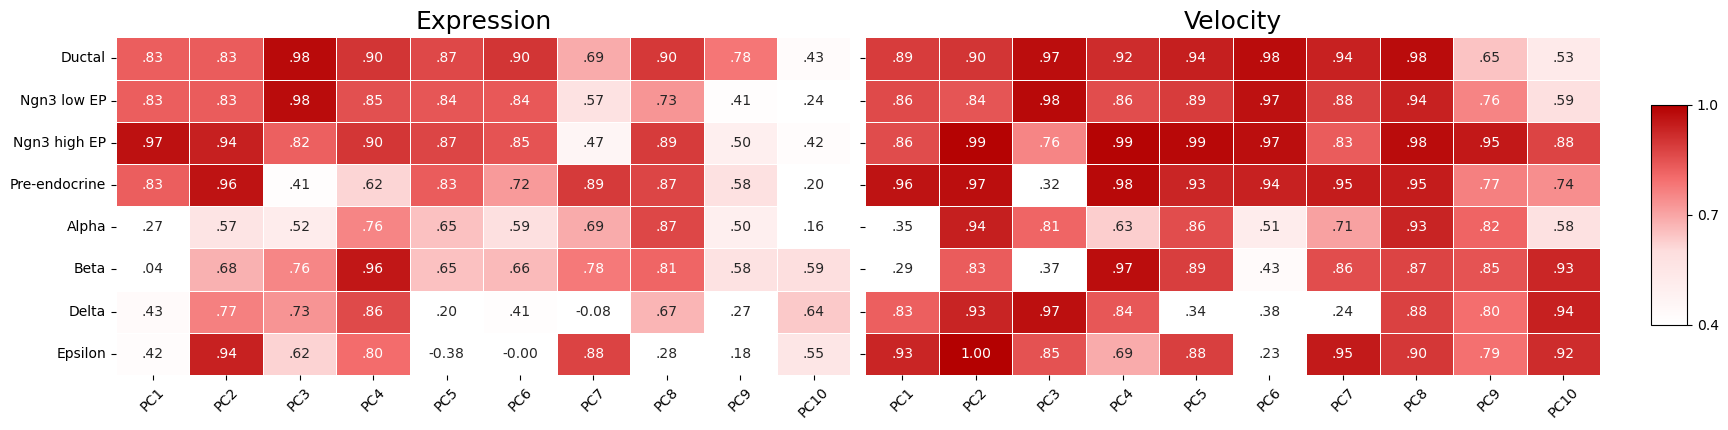

In [6]:
def fmt_score(x):
    if pd.isna(x):
        return ""
    s = f"{x:.2f}"
    return s[1:] if s.startswith("0") else s


def plot_pc_heatmaps(expr_scores, vel_scores):
    cell_type_order = [
        "Ductal", "Ngn3 low EP", "Ngn3 high EP", "Pre-endocrine",
        "Alpha", "Beta", "Delta", "Epsilon",
    ]
    cell_type_order = [ct for ct in cell_type_order if ct in expr_scores.index]
    expr_scores = expr_scores.reindex(cell_type_order)
    vel_scores = vel_scores.reindex(cell_type_order)

    cmap_r2 = LinearSegmentedColormap.from_list(
        "white_red",
        ["#ffffff", "#fddede", "#f46d6d", "#b30000"],
    )

    fig, axes = plt.subplots(
        1, 2,
        figsize=(1.2 * expr_scores.shape[1] + 6, 0.55 * expr_scores.shape[0]),
        sharey=True,
    )

    for ax, scores, title in zip(axes, [expr_scores, vel_scores], ["Expression", "Velocity"]):
        sns.heatmap(
            scores,
            ax=ax,
            cmap=cmap_r2,
            vmin=0.4,
            vmax=1.0,
            linewidths=0.4,
            cbar=False,
            annot=scores.applymap(fmt_score),
            fmt="",
            annot_kws={"fontsize": 10},
        )
        ax.set_title(title, fontsize=18)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(axis="x", labelrotation=45)
        ax.tick_params(axis="y", labelrotation=0)

    cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])
    sm = plt.cm.ScalarMappable(cmap=cmap_r2, norm=plt.Normalize(vmin=0.4, vmax=1.0))
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, ticks=[0.4, 0.7, 1.0])

    plt.tight_layout(rect=[0, 0, 0.9, 1])
    return fig

plot_pc_heatmaps(pc_expr_scores, pc_vel_scores)
plt.show()


## 6. Raw PC velocity

The PC-level heatmaps suggest that PC3 and PC8 have relatively high consistency with the embedding. We can inspect the raw velocity vectors directly in that PC plane.

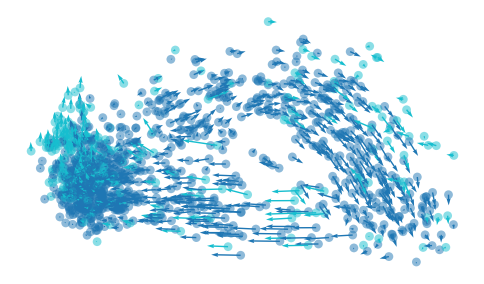

In [7]:
pc_x, pc_y = 2, 7
X_pc = adata.obsm["X_pca"][:, [pc_x, pc_y]]
V_pc = adata.obsm["stochastic_velocity_pca"][:, [pc_x, pc_y]]

mask = np.isin(cell_type, ["Ductal", "Ngn3 low EP"])
plot_2d_quiver(
    X_pc[mask],
    V_pc[mask],
    color=(cell_type[mask] == "Ngn3 low EP").astype(float),
    scale=0.4,
    size=40,
    alpha=0.5,
    cmap="tab10",
)
plt.show()

## 7. Fit gene-level splines

By default, this tutorial fits FlowMap in PC space. For gene-level evaluation, we can either use the PC-level reconstruction as an approximation or refit splines directly from the embedding to genes. Here we refit the gene-level splines using all highly variable genes.

In [8]:
gene_idx = np.flatnonzero(hvg_mask)
X_gene = to_dense(adata.layers["spliced"][:, gene_idx]).astype(np.float32)
V_gene = to_dense(adata.layers["stochastic_velocity"][:, gene_idx]).astype(np.float32)
gene_names = adata.var_names[gene_idx].to_numpy()

emb.fit_gene_level_splines(
    X=X_gene,
    V=V_gene,
    dof_gene=50,
    dof_vf_gene=50,
)

[Spline-Gene] Fitting expression spline on 3696 cells …
[Spline] Using all 3696 points as control points.
[Spline-Gene] Mapping velocities …
[Spline-Gene] Fitting velocity spline …
[Spline] Using all 3696 points as control points.
[Spline-Gene] Done. X_gene (3696, 1945), V_gene (3696, 1945)


## 8. Gene-level evaluation

Each panel shows per-gene expression and velocity reconstruction within one cell type. The top five genes by average score are highlighted.

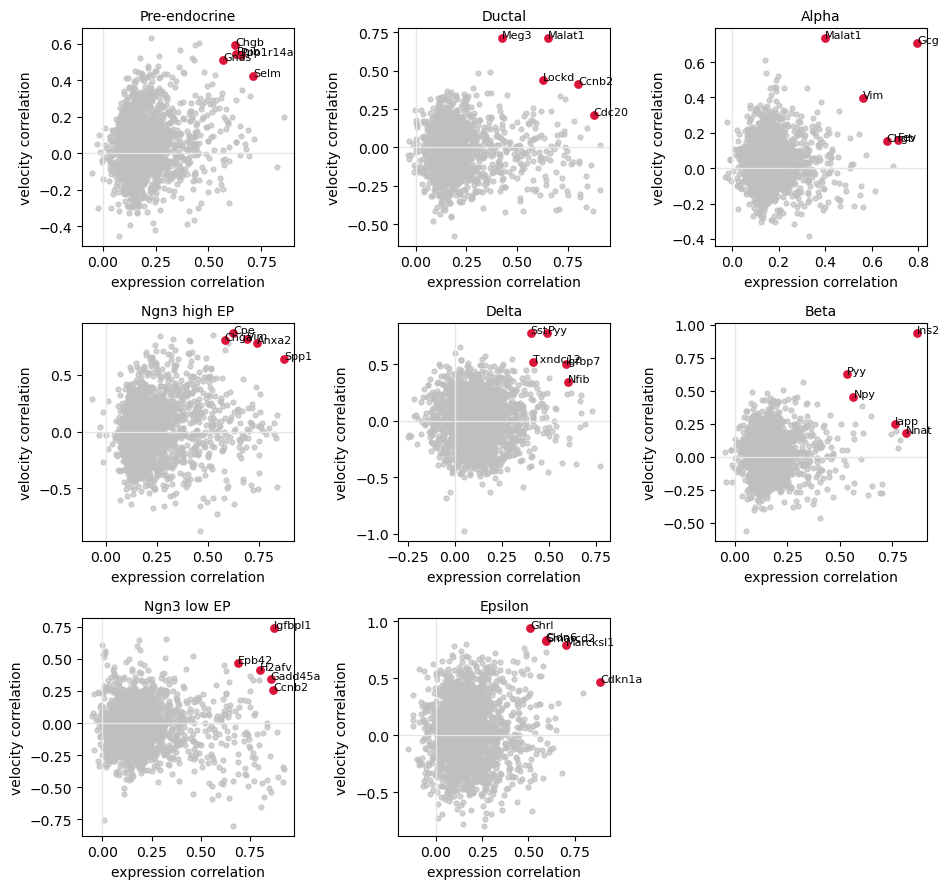

In [9]:
def gene_scores_by_cell_type(evaluator, labels, min_cells=10):
    scores = {}
    for label in pd.unique(labels):
        idx = np.where(labels == label)[0]
        if len(idx) < min_cells:
            continue

        result = evaluator.evaluate(cell_idx=idx)
        scores[label] = pd.DataFrame({
            "gene": gene_names,
            "expression": result["expr_corr_gene"],
            "velocity": result["vel_corr_gene"],
        })
    return scores


def plot_gene_scatter(scores_by_group, top_n=5, ncols=3):
    labels = list(scores_by_group)
    nrows = int(np.ceil(len(labels) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.0 * nrows), squeeze=False)

    for ax, label in zip(axes.ravel(), labels):
        df = scores_by_group[label].replace([np.inf, -np.inf], np.nan).dropna()
        score = df[["expression", "velocity"]].mean(axis=1)
        top = df.iloc[np.argsort(score.to_numpy())[-top_n:]]

        ax.scatter(df["expression"], df["velocity"], s=12, color="0.75", alpha=0.7)
        ax.scatter(top["expression"], top["velocity"], s=28, color="crimson")
        for _, row in top.iterrows():
            ax.text(row["expression"], row["velocity"], row["gene"], fontsize=8)

        ax.axhline(0, color="0.9", lw=1)
        ax.axvline(0, color="0.9", lw=1)
        ax.set_title(label, fontsize=10)
        ax.set_xlabel("expression correlation")
        ax.set_ylabel("velocity correlation")

    for ax in axes.ravel()[len(labels):]:
        ax.axis("off")

    plt.tight_layout()
    return fig


gene_scores = gene_scores_by_cell_type(SplineFitEvaluator(emb, mode="gene"), cell_type)
plot_gene_scatter(gene_scores, top_n=5)
plt.show()